# SAAM Project - Pacific Region

Sustainable & Active Asset Management - portfolio construction with carbon constraints.

This notebook is fully self-contained: it reads the project input files directly from `data/` and produces every table in `outputs/tables/` and every figure in `outputs/figures/`.

Structure:
1. Setup
2. Short introduction
3. Data loading and cleaning
4. Part 1 - Minimum-Variance Portfolio (P_mv)
5. Part 2 - Value-Weighted benchmark (P_vw)
6. Part 3 - 50% carbon-footprint reduction (P_mv_50, P_vw_50)
7. Part 4 - Net-Zero trajectory (P_vw_NZ)
8. Final performance summary
9. Short conclusion

## 1. Setup

Imports, robust pathlib paths, methodology constants, and output folders.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

ROOT = Path.cwd()
if ROOT.name == "src":
    ROOT = ROOT.parent
RAW       = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
TABLES    = ROOT / "outputs" / "tables"
FIGURES   = ROOT / "outputs" / "figures"
for d in (PROCESSED, TABLES, FIGURES):
    d.mkdir(parents=True, exist_ok=True)

YEAR_FIRST     = 2013
YEAR_LAST      = 2024
PERF_START     = 2014
PERF_END       = 2025
ESTIM_MONTHS   = 120
MIN_OBS        = 36
STALE_THRESHOLD = 0.50
RIDGE_EPS      = 1e-6
THETA_NZ       = 0.10
CARBON_SCOPE   = "scope1"

pd.options.display.float_format = "{:,.4f}".format
print("Setup OK. ROOT =", ROOT)

Setup OK. ROOT = c:\Users\ish4q\Desktop\dummy\saam notebook package copy


## 2. Short introduction

We build five portfolios on the Pacific equity universe and compare their financial **and** carbon performance over 2014-2025:

- **P_vw**: market-cap weighted benchmark, monthly rebalanced (Section 2.3).
- **P_mv**: long-only minimum-variance portfolio, annually rebalanced, intra-year drift (Section 2.2).
- **P_mv_50**: minimum variance with carbon footprint capped at 50% of P_mv (Section 3.2).
- **P_vw_50**: tracking-error minimisation vs P_vw with the same 50% CF cap (Section 3.3).
- **P_vw_NZ**: tracking-error minimisation vs P_vw with a declining Net-Zero cap, -10% per year from the 2013 anchor (Section 4).

Carbon metrics:
- WACI = $\\sum_i w_i\\, \\text{CI}_i$ with $\\text{CI}_i = E_i / (\\text{Rev}_i / 1000)$ (tCO2e per M$ revenue).
- Carbon Footprint CF = $\\sum_i w_i \\, (E_i / \\text{Cap}_i)$ (tCO2e per M$ invested).

## 3. Data loading and cleaning

Cleaning rules applied here:
- Filter the Static file to the PAC region to build the reference universe.
- Convert Datastream error strings and non-numeric values to `NaN`.
- Set total return index prices below 0.5 to `NaN`.
- Compute simple monthly returns as `P_t / P_{t-1} - 1`.
- Treat delistings as a `-100%` return in the first month after the last valid price, then `NaN` afterwards.
- Forward-fill missing annual CO2 and revenue values between two available years.
- Convert the risk-free rate file into the monthly decimal series used for Sharpe ratios.

### Building the PAC reference file (`static_pac.csv`)
Loads `Static_2025.xlsx` containing information for all firms (ISIN, name, country, region). Filters only firms classified under the **PAC** (Pacific) region — regardless of the ISIN prefix. Saves the result to `static_pac.csv`.

In [2]:
static = pd.read_excel(RAW / "Static_2025.xlsx")

static_pac = static[static["Region"] == "PAC"][["ISIN", "NAME", "Country"]]

print(f"Number of PAC firms: {len(static_pac)}")

static_pac.to_csv(PROCESSED / "static_pac.csv", index=False)

print("static_pac.csv created")

Number of PAC firms: 513
static_pac.csv created


### Cleaning CO2 Scope 1 emissions (`co2_scope1.csv`)
Loads CO2 Scope 1 emissions from `DS_CO2_SCOPE_1_Y_2025.xlsx`. Filters PAC firms by cross-referencing with `static_pac.csv`. Excludes firms with more than 50% missing values over the years 2010–2024. Transposes the result (rows = years, columns = ISIN) and saves to `co2_scope1.csv`.

In [3]:
pacific_isins = static_pac["ISIN"].tolist()

df = pd.read_excel(RAW / "DS_CO2_SCOPE_1_Y_2025.xlsx")
df_pacific = df[df["ISIN"].isin(pacific_isins)].copy()

years_co2 = list(range(2010, 2025))

# Keep useful columns only
df_co2 = df_pacific[["ISIN", "NAME"] + years_co2].copy()

# Convert blanks / strings to NaN, then numeric
df_co2[years_co2] = df_co2[years_co2].replace(r"^\s*$", np.nan, regex=True)
df_co2[years_co2] = df_co2[years_co2].apply(pd.to_numeric, errors="coerce")

# In this file, missing CO2 values may be encoded as 0.0
# Treat zeros as missing before applying forward-fill
df_co2[years_co2] = df_co2[years_co2].replace(0, np.nan)

# Drop firms with no usable CO2 data at all over the available carbon period
df_co2 = df_co2[df_co2[years_co2].notna().any(axis=1)]

# Convert to time-series format
df_final = df_co2.drop(columns=["NAME"]).set_index("ISIN")[years_co2].T
df_final.index = pd.to_datetime(df_final.index.astype(int).astype(str) + "-12-31")
df_final.index.name = "Date"

# Forward-fill only one year ahead
df_final = df_final.ffill(limit=1)

print(f"Shape: {df_final.shape}")
df_final.to_csv(PROCESSED / "co2_scope1.csv")

Shape: (15, 495)


### Cleaning prices and computing returns (`prices_clean.csv`, `returns.csv`)
Loads monthly prices from `DS_RI_T_USD_M_2025.xlsx`. Filters PAC firms via `static_pac.csv`. Applies the following cleaning steps:
- Converts Datastream error strings (`$$ER:...`) to NaN
- Excludes firms with more than 50% missing data
- Replaces prices below 0.5 with NaN (low prices)

Computes simple returns (Rₜ = Pₜ/Pₜ₋₁ − 1). Handles delisting: assigns a return of **-100%** at the first month after the last valid price, and NaN thereafter.

In [4]:
df = pd.read_excel(RAW / "DS_RI_T_USD_M_2025.xlsx")
date_cols = [c for c in df.columns if c not in ['NAME', 'ISIN']]
df[date_cols] = df[date_cols].apply(pd.to_numeric, errors='coerce')

df_pacific = df[df['ISIN'].isin(pacific_isins)]
df_pacific = df_pacific[df_pacific[date_cols].isna().mean(axis=1) <= 0.5].copy()
df_pacific[date_cols] = df_pacific[date_cols].where(df_pacific[date_cols] >= 0.5, np.nan)

prices = df_pacific.set_index("ISIN")[date_cols].T
prices.index = pd.to_datetime(prices.index)
prices = prices.sort_index()

rets = prices / prices.shift(1) - 1
for isin in prices.columns:
    series = prices[isin]
    last_valid = series[series > 0].last_valid_index()
    if last_valid is not None and last_valid < prices.index[-1]:
        next_pos   = prices.index.get_loc(last_valid) + 1
        delist_date = prices.index[next_pos]
        rets.loc[delist_date, isin] = -1.0
        rets.loc[rets.index > delist_date, isin] = np.nan
rets = rets.replace([np.inf, -np.inf], np.nan)

prices.to_csv(PROCESSED / "prices_clean.csv")
rets.to_csv(PROCESSED / "returns.csv")
print(f"Number of PAC firms: {prices.shape[1]}")
print("prices_clean.csv and returns.csv created")

Number of PAC firms: 509
prices_clean.csv and returns.csv created


### Revenues, market cap, and risk-free rate
Loads annual revenues, monthly and annual market capitalisations, and the risk-free rate. All panels are filtered to the PAC universe and saved to `data/processed/`.

In [5]:
# Revenues (annual)
df = pd.read_excel(RAW / "DS_REV_Y_2025.xlsx")
df_pacific = df[df["ISIN"].isin(pacific_isins)]
rev_final = df_pacific.drop(columns=["NAME"]).set_index("ISIN").T
rev_final.index = pd.to_datetime(rev_final.index.astype(int).astype(str) + "-12-31")
rev_final.index.name = "Date"
rev_final.to_csv(PROCESSED / "revenues yearly.csv")

# Market cap (monthly)
df = pd.read_excel(RAW / "DS_MV_T_USD_M_2025.xlsx")
df_pacific = df[df["ISIN"].isin(pacific_isins)]
cap_m_final = df_pacific.drop(columns=["NAME"]).set_index("ISIN").T
cap_m_final.index = pd.to_datetime(cap_m_final.index)
cap_m_final.index.name = "Date"
cap_m_final.to_csv(PROCESSED / "market values monthly.csv")

# Market cap (annual)
df = pd.read_excel(RAW / "DS_MV_T_USD_Y_2025.xlsx")
df_pacific = df[df["ISIN"].isin(pacific_isins)]
cap_y_final = df_pacific.drop(columns=["NAME"]).set_index("ISIN").T
cap_y_final.index = pd.to_datetime(cap_y_final.index.astype(int).astype(str) + "-12-31")
cap_y_final.index.name = "Date"
cap_y_final.to_csv(PROCESSED / "market values yearly.csv")

# Risk-free rate
df_rf = pd.read_excel(RAW / "Risk_Free_Rate_2025.xlsx")
df_rf.columns = ["Date", "RF"]
df_rf.to_csv(PROCESSED / "risk_free_rate.csv", index=False)

print("revenues yearly.csv, market values monthly.csv, market values yearly.csv, risk_free_rate.csv created")

revenues yearly.csv, market values monthly.csv, market values yearly.csv, risk_free_rate.csv created


### Aligning all panels on a common universe

Once all raw files are cleaned, the panels are loaded back in the format expected by the portfolio construction loop: ISIN-indexed annual series for carbon data, revenues, and market cap; date-indexed monthly series for prices, returns, and market cap. All panels are restricted to the common set of ISINs that have data across all sources.

In [6]:
names     = static_pac.set_index("ISIN")["NAME"].astype(str)
countries = static_pac.set_index("ISIN")["Country"].astype(str)

# emissions: Timestamp index (YYYY-12-31), columns = ISINs
emissions = pd.read_csv(PROCESSED / "co2_scope1.csv", index_col=0, parse_dates=True)
emissions = emissions.apply(pd.to_numeric, errors="coerce").ffill()

# revenues: Timestamp index (YYYY-12-31), columns = ISINs
revenues = pd.read_csv(PROCESSED / "revenues yearly.csv", index_col=0, parse_dates=True)
revenues = revenues.apply(pd.to_numeric, errors="coerce").ffill()

# cap_y: Timestamp index (YYYY-12-31), columns = ISINs
cap_y = pd.read_csv(PROCESSED / "market values yearly.csv", index_col=0, parse_dates=True)
cap_y = cap_y.apply(pd.to_numeric, errors="coerce").ffill()

# cap_m: Timestamp index (month-end), columns = ISINs
cap_m = pd.read_csv(PROCESSED / "market values monthly.csv", index_col=0, parse_dates=True)
cap_m = cap_m.apply(pd.to_numeric, errors="coerce").sort_index()

# risk-free rate: monthly decimal series indexed by month-end Timestamp
rf_raw = pd.read_csv(PROCESSED / "risk_free_rate.csv")
rf_raw.columns  = ["period", "rf"]
rf_raw["period"] = pd.to_datetime(rf_raw["period"].astype(str).str.zfill(6), format="%Y%m") + pd.offsets.MonthEnd(0)
rf_raw["rf"]     = pd.to_numeric(rf_raw["rf"], errors="coerce")
rf_raw = rf_raw.dropna()
rf_monthly = pd.Series(rf_raw["rf"].to_numpy() / 100.0, index=rf_raw["period"], name="rf").sort_index()

# Align all panels on common ISINs
common = (prices.columns
          .intersection(emissions.columns)
          .intersection(revenues.columns)
          .intersection(cap_y.columns))
prices    = prices[common]
rets      = rets[common]
emissions = emissions[common]
revenues  = revenues[common]
cap_y     = cap_y[common]
cap_m     = cap_m.loc[:, cap_m.columns.intersection(common)]

print(f"Aligned universe: {len(common)} ISINs | rets {rets.shape} | rf_monthly {rf_monthly.shape}")

Aligned universe: 491 ISINs | rets (314, 491) | rf_monthly (312,)


### Helper functions

Three reusable helpers:
- `build_year_inputs(Y)`: eligible universe, complete-case covariance, value weights, carbon vectors at end-of-Y.
- `solve_qp(...)`: long-only QP (variance or tracking error) with an optional carbon-footprint cap.
- `simulate_year(weights, returns)`: monthly portfolio returns over the implementation year, weights drift (no intra-year rebalancing).

In [7]:
def build_year_inputs(year):
    est_start = pd.Timestamp(year - 9, 1, 1)
    est_end   = pd.Timestamp(year, 12, 31)
    oos_start = pd.Timestamp(year + 1, 1, 1)
    oos_end   = pd.Timestamp(year + 1, 12, 31)

    rets_win = rets.loc[est_start:est_end]
    rets_oos = rets.loc[oos_start:oos_end]

    obs        = rets_win.count()
    zero_ratio = (rets_win == 0.0).sum() / obs.replace(0, np.nan)
    last_px_ok = prices.loc[:est_end].iloc[-1].gt(0)

    dec_y = pd.Timestamp(year, 12, 31)
    eligible = (
        emissions.loc[dec_y].notna()
        & revenues.loc[dec_y].gt(0)
        & cap_y.loc[dec_y].gt(0)
        & last_px_ok.reindex(emissions.columns).fillna(False)
        & obs.reindex(emissions.columns).ge(MIN_OBS).fillna(False)
        & zero_ratio.reindex(emissions.columns).le(STALE_THRESHOLD).fillna(False)
    )
    isins = sorted(eligible[eligible].index.intersection(rets_oos.columns))
    if not isins:
        raise RuntimeError(f"No eligible firms for year {year}")

    rets_est = rets_win[isins].iloc[-ESTIM_MONTHS:]
    complete = rets_est.dropna(how="any")
    if len(complete) < MIN_OBS:
        filled = rets_est.apply(lambda s: s.fillna(s.mean())).fillna(0.0)
        cov = np.cov(filled.to_numpy(), rowvar=False, ddof=0)
    else:
        cov = np.cov(complete.to_numpy(), rowvar=False, ddof=0)
    cov = (cov + cov.T) / 2.0 + RIDGE_EPS * np.eye(len(isins))

    cap_yi = cap_y.loc[dec_y, isins].astype(float)
    emi_yi = emissions.loc[dec_y, isins].astype(float)
    rev_yi = revenues.loc[dec_y, isins].astype(float)
    return {
        "year": year, "isins": isins,
        "rets_oos": rets_oos[isins],
        "cov": cov,
        "ci":       emi_yi / (rev_yi / 1000.0),
        "cf_per_w": emi_yi / cap_yi,
        "w_vw":     (cap_yi / cap_yi.sum()).to_numpy(),
    }

In [8]:
def solve_qp(cov, objective="variance", benchmark=None, carbon=None, carbon_limit=None):
    n     = cov.shape[0]
    bench = np.full(n, 1.0 / n) if benchmark is None else np.asarray(benchmark, float)
    x0    = bench.copy() if objective == "tracking_error" else np.full(n, 1.0 / n)

    if carbon is not None and carbon_limit is not None and float(x0 @ carbon) > carbon_limit:
        unit = np.zeros(n); unit[int(np.argmin(carbon))] = 1.0
        base, low = float(x0 @ carbon), float(unit @ carbon)
        if low > carbon_limit:
            x0 = unit
        else:
            alpha = float(np.clip((base - carbon_limit) / max(base - low, 1e-12) + 1e-3, 0.0, 1.0))
            x0 = (1.0 - alpha) * x0 + alpha * unit

    if objective == "variance":
        fun = lambda w: float(w @ cov @ w)
        jac = lambda w: 2.0 * cov @ w
    else:
        b   = bench
        fun = lambda w: float((w - b) @ cov @ (w - b))
        jac = lambda w: 2.0 * cov @ (w - b)

    cons = [{"type": "eq", "fun": lambda w: float(w.sum() - 1.0),
             "jac": lambda w: np.ones_like(w)}]
    if carbon is not None and carbon_limit is not None:
        c = np.asarray(carbon, float); L = float(carbon_limit)
        cons.append({"type": "ineq",
                     "fun": lambda w, c=c, L=L: float(L - w @ c),
                     "jac": lambda w, c=c: -c})

    res = minimize(fun, x0, jac=jac, method="SLSQP", bounds=[(0.0, 1.0)] * n,
                   constraints=cons, options={"maxiter": 200, "ftol": 1e-8, "disp": False})
    w = np.clip(res.x, 0.0, None)
    if w.sum() > 0:
        w = w / w.sum()
    ok = bool(res.success)
    if carbon is not None and carbon_limit is not None:
        ok = ok and float(w @ np.asarray(carbon, float)) <= carbon_limit + 1e-6
    return w, ok, str(res.message)


def simulate_year(weights, rets_oos):
    w   = weights.copy()
    out = {}
    for date, row in rets_oos.fillna(0.0).iterrows():
        r  = row.to_numpy(float)
        rp = float(w @ r)
        out[date] = rp
        if 1.0 + rp <= 0.0:
            break
        w = np.clip(w * (1.0 + r) / (1.0 + rp), 0.0, None)
        if w.sum() > 0:
            w = w / w.sum()
    return pd.Series(out, dtype=float)


def vw_monthly_rebalanced():
    cap = cap_m.reindex(index=rets.index, columns=rets.columns)
    w   = cap.div(cap.sum(axis=1), axis=0).shift(1)
    return (w * rets).sum(axis=1, min_count=1)

### Annual loop: solving the portfolios year by year

The portfolio construction is done in an annual loop from 2013 to 2024. For each year, we rebuild the eligible universe, estimate the covariance matrix, compute the benchmark weights, and solve the five portfolio problems using the same yearly inputs. Each portfolio for year Y+1 uses only information available at end of year Y.

In [9]:
yi_anchor    = build_year_inputs(YEAR_FIRST)
cf_vw_anchor = float(yi_anchor["w_vw"] @ yi_anchor["cf_per_w"].to_numpy())
print(f"Anchor CF(P_vw)_{YEAR_FIRST} = {cf_vw_anchor:.4f} tCO2e/M$")

labels     = ["vw_drift", "mv", "mv_50", "vw_50", "vw_nz"]
month_segs = {lab: [] for lab in labels}
annual_rows, weight_rows, te_rows, slack_rows = [], [], [], []
waci_top_rows, cf_top_rows, path_rows = [], [], []

for year in range(YEAR_FIRST, YEAR_LAST + 1):
    yi     = build_year_inputs(year)
    carbon = yi["cf_per_w"].to_numpy()
    ci_vec = yi["ci"].to_numpy()
    w_vw   = yi["w_vw"]
    cf_vw  = float(w_vw @ carbon)

    w_mv,   ok_mv,   msg_mv   = solve_qp(yi["cov"], "variance")
    cf_mv = float(w_mv @ carbon)
    w_mv50, ok_mv50, msg_mv50 = solve_qp(yi["cov"], "variance",
                                          carbon=carbon, carbon_limit=0.5 * cf_mv)
    w_vw50, ok_vw50, msg_vw50 = solve_qp(yi["cov"], "tracking_error", benchmark=w_vw,
                                          carbon=carbon, carbon_limit=0.5 * cf_vw)
    cap_nz = ((1.0 - THETA_NZ) ** (year - YEAR_FIRST + 1)) * cf_vw_anchor
    w_nz,   ok_nz,   msg_nz   = solve_qp(yi["cov"], "tracking_error", benchmark=w_vw,
                                          carbon=carbon, carbon_limit=cap_nz)

    portfolios = {
        "vw_drift": (w_vw,   True,    "benchmark (drift)", cf_vw),
        "mv":       (w_mv,   ok_mv,   msg_mv,              np.nan),
        "mv_50":    (w_mv50, ok_mv50, msg_mv50,            0.5 * cf_mv),
        "vw_50":    (w_vw50, ok_vw50, msg_vw50,            0.5 * cf_vw),
        "vw_nz":    (w_nz,   ok_nz,   msg_nz,              cap_nz),
    }

    bench_series = None
    for lab, (w, ok, msg, cap_lim) in portfolios.items():
        s = simulate_year(w, yi["rets_oos"])
        month_segs[lab].append(s)
        if lab == "vw_drift":
            bench_series = s

        cf  = float(w @ carbon)
        wc  = float(w @ ci_vec)
        cap_val = None if (isinstance(cap_lim, float) and np.isnan(cap_lim)) else cap_lim
        annual_rows.append({
            "year": year, "implementation_year": year + 1, "portfolio": lab,
            "n_assets": len(yi["isins"]),
            "waci_tco2e_per_musd_revenue": wc,
            "carbon_footprint_tco2e_per_musd_invested": cf,
            "carbon_limit": cap_lim,
            "optimization_success": bool(ok), "optimization_message": msg,
        })
        slack_rows.append({
            "year": year, "implementation_year": year + 1, "portfolio": lab,
            "carbon_footprint": cf,
            "carbon_limit":     cap_val if cap_val is not None else np.nan,
            "slack":            (cap_val - cf) if cap_val is not None else np.nan,
            "satisfied_within_1e-6": bool(cap_val is None or (cap_val - cf) >= -1e-6),
            "optimization_success": bool(ok), "optimization_message": msg,
        })

        active = pd.Series(w, index=yi["isins"])
        for isin, weight in active[active > 1e-6].sort_values(ascending=False).items():
            weight_rows.append({
                "year": year, "portfolio": lab, "ISIN": isin,
                "name": names.get(isin, ""), "country": countries.get(isin, ""),
                "weight": float(weight),
                "ci": float(yi["ci"].get(isin, np.nan)),
                "cf_per_weight": float(yi["cf_per_w"].get(isin, np.nan)),
            })

        diff_w   = w - w_vw
        ex_ante  = float(np.sqrt(max(diff_w @ yi["cov"] @ diff_w, 0.0) * 12.0))
        ex_post  = np.nan
        if lab != "vw_drift" and bench_series is not None:
            rel = (s.reindex(bench_series.index) - bench_series).dropna()
            if len(rel) > 1:
                ex_post = float(rel.std(ddof=0) * np.sqrt(12.0))
        te_rows.append({
            "year": year, "implementation_year": year + 1, "portfolio": lab,
            "ex_ante_tracking_error_annual": ex_ante,
            "ex_post_tracking_error_annual": ex_post,
        })

    contrib = pd.DataFrame({
        "ISIN":    yi["isins"],
        "name":    names.reindex(yi["isins"]).to_numpy(),
        "country": countries.reindex(yi["isins"]).to_numpy(),
        "ci_tco2e_per_musd_revenue":              ci_vec,
        "cf_per_weight_tco2e_per_musd_invested":  carbon,
        "vw_weight":             w_vw,
        "vw_waci_contribution":  w_vw * ci_vec,
        "vw_cf_contribution":    w_vw * carbon,
    })
    top_waci = contrib.sort_values("vw_waci_contribution", ascending=False).head(10)
    for rank, row in enumerate(top_waci.itertuples(index=False), start=1):
        waci_top_rows.append({
            "year": year, "rank": rank, "ISIN": row.ISIN, "name": row.name,
            "country": row.country,
            "ci_tco2e_per_musd_revenue": row.ci_tco2e_per_musd_revenue,
            "vw_weight": row.vw_weight,
            "vw_waci_contribution": row.vw_waci_contribution,
        })
    top_cf = contrib.sort_values("vw_cf_contribution", ascending=False).head(10)
    for rank, row in enumerate(top_cf.itertuples(index=False), start=1):
        cf_top_rows.append({
            "year": year, "rank": rank, "ISIN": row.ISIN, "name": row.name,
            "country": row.country,
            "cf_per_weight_tco2e_per_musd_invested": row.cf_per_weight_tco2e_per_musd_invested,
            "vw_weight": row.vw_weight,
            "vw_cf_contribution": row.vw_cf_contribution,
        })

    cf_vw_nz = float(w_nz @ carbon)
    path_rows.append({
        "year": year, "implementation_year": year + 1,
        "anchor_cf_vw_2013": cf_vw_anchor, "theta": THETA_NZ,
        "carbon_limit_nz": cap_nz,
        "carbon_footprint_vw": cf_vw,
        "carbon_footprint_vw_nz": cf_vw_nz,
        "slack": cap_nz - cf_vw_nz,
        "feasible_within_1e-6": bool((cap_nz - cf_vw_nz) >= -1e-6),
        "optimizer_success": bool(ok_nz),
    })

    print(f"{year}: n={len(yi['isins']):>3} | CF vw={cf_vw:7.2f}  mv={cf_mv:7.2f}  "
          f"mv50={float(w_mv50@carbon):7.2f}  vw50={float(w_vw50@carbon):7.2f}  "
          f"vw_nz={cf_vw_nz:7.2f} (cap={cap_nz:6.2f})")

print("\nAnnual loop done.")

Anchor CF(P_vw)_2013 = 158.9359 tCO2e/M$
2013: n=233 | CF vw= 158.94  mv= 213.09  mv50= 106.54  vw50=  79.47  vw_nz= 141.35 (cap=143.04)
2014: n=246 | CF vw= 144.25  mv= 509.46  mv50= 254.73  vw50=  71.61  vw_nz= 107.62 (cap=128.74)
2015: n=268 | CF vw= 188.24  mv= 442.33  mv50= 221.17  vw50=  94.12  vw_nz= 115.86 (cap=115.86)
2016: n=294 | CF vw= 240.37  mv= 508.54  mv50= 254.27  vw50= 120.18  vw_nz= 104.28 (cap=104.28)
2017: n=324 | CF vw= 211.40  mv= 499.70  mv50= 249.85  vw50= 105.70  vw_nz=  93.85 (cap= 93.85)
2018: n=353 | CF vw= 178.49  mv= 155.49  mv50=  77.75  vw50=  69.88  vw_nz=  70.55 (cap= 84.47)
2019: n=392 | CF vw= 190.98  mv= 316.42  mv50= 158.21  vw50=  88.46  vw_nz=  76.02 (cap= 76.02)
2020: n=422 | CF vw= 155.69  mv= 471.88  mv50= 235.94  vw50=  77.84  vw_nz=  68.42 (cap= 68.42)
2021: n=454 | CF vw= 151.92  mv= 657.94  mv50= 328.97  vw50=  75.85  vw_nz=  61.58 (cap= 61.58)
2022: n=467 | CF vw= 153.06  mv= 505.73  mv50= 252.87  vw50=  74.44  vw_nz=  55.42 (cap= 55.42)

In [10]:
monthly = pd.DataFrame({lab: pd.concat(month_segs[lab]).sort_index() for lab in labels})
monthly = monthly.loc[f"{PERF_START}-01-01":f"{PERF_END}-12-31"]

vw_monthly = vw_monthly_rebalanced().loc[f"{PERF_START}-01-01":f"{PERF_END}-12-31"]
monthly["vw"] = vw_monthly.reindex(monthly.index)
monthly = monthly[["vw", "vw_drift", "mv", "mv_50", "vw_50", "vw_nz"]]

annual      = pd.DataFrame(annual_rows)
weights     = pd.DataFrame(weight_rows)
te_table    = pd.DataFrame(te_rows)
slack_table = pd.DataFrame(slack_rows)
waci_top    = pd.DataFrame(waci_top_rows)
cf_top      = pd.DataFrame(cf_top_rows)
path_table  = pd.DataFrame(path_rows)

for idx, row in te_table.iterrows():
    lab = row["portfolio"]
    if lab == "vw_drift" or lab not in monthly.columns:
        continue
    year = int(row["implementation_year"])
    rel  = (monthly.loc[f"{year}-01-01":f"{year}-12-31", lab]
            - monthly.loc[f"{year}-01-01":f"{year}-12-31", "vw"]).dropna()
    te_table.at[idx, "ex_post_tracking_error_annual"] = float(rel.std(ddof=0) * np.sqrt(12.0)) if len(rel) > 1 else np.nan

monthly.to_csv(TABLES / "all_portfolio_monthly_returns.csv", index_label="date")
annual.to_csv(TABLES / "all_portfolio_annual_carbon_metrics.csv", index=False)
weights.to_csv(TABLES / "all_portfolio_weights.csv", index=False)
te_table.to_csv(TABLES / "all_portfolio_tracking_errors.csv", index=False)
slack_table.to_csv(TABLES / "all_portfolio_constraint_slack.csv", index=False)

constrained  = slack_table[slack_table["carbon_limit"].notna() & (slack_table["portfolio"] != "vw_drift")]
worst_slack  = constrained["slack"].min()
assert worst_slack >= -1e-6, f"Carbon constraint violated: min slack = {worst_slack}"
print(f"Monthly panel: {monthly.shape} | min carbon slack = {worst_slack:.3e}")
print("Constructed portfolios:", ", ".join(monthly.columns))
monthly.head()

Monthly panel: (144, 6) | min carbon slack = -2.274e-13
Constructed portfolios: vw, vw_drift, mv, mv_50, vw_50, vw_nz


,vw,vw_drift,mv,mv_50,vw_50,vw_nz
2014-01-31,-0.0440,-0.0394,-0.0262,-0.0308,-0.0386,-0.0396
2014-02-28,0.0194,0.0298,0.0474,0.0451,0.0309,0.0264
2014-03-31,0.0028,0.0067,0.0149,0.0168,-0.0003,0.0062
2014-04-30,-0.0064,-0.0011,0.0123,0.0124,-0.0017,-0.0018
2014-05-30,0.0306,0.0278,0.0425,0.0483,0.0215,0.0267


### Difference between `vw_drift` and `vw`

The annual loop first creates `vw_drift`, which is the value-weighted portfolio formed at the annual allocation date and then allowed to drift during the implementation year.

For the final benchmark, the notebook also constructs `vw`, which is the strict monthly value-weighted benchmark using previous-month market capitalisation weights. This is the benchmark used in the final performance table and for tracking error.

In [11]:
def summary_stats(panel, rf, benchmark="vw"):
    rf_by_month = rf.copy()
    rf_by_month.index = rf_by_month.index.to_period("M")
    rows  = []
    bench = panel[benchmark] if benchmark in panel.columns else None
    for col in panel.columns:
        r = panel[col].dropna()
        if not len(r):
            continue
        ann_ret  = float(r.mean() * 12.0)
        ann_vol  = r.std(ddof=0) * np.sqrt(12.0)
        rf_aligned = rf_by_month.reindex(r.index.to_period("M"))
        valid_rf   = rf_aligned.notna().to_numpy()
        ann_rf     = float(rf_aligned.dropna().mean() * 12.0) if valid_rf.any() else 0.0
        ret_to_vol = ann_ret / ann_vol if ann_vol > 0 else np.nan
        if ann_vol > 0 and valid_rf.any():
            ann_excess    = float((r.to_numpy()[valid_rf] - rf_aligned.to_numpy()[valid_rf]).mean() * 12.0)
            excess_sharpe = ann_excess / ann_vol
        elif ann_vol > 0:
            excess_sharpe = ann_ret / ann_vol
        else:
            excess_sharpe = np.nan
        te = np.nan
        if bench is not None and col != benchmark:
            diff = (panel[col] - bench).dropna()
            te   = float(diff.std(ddof=0) * np.sqrt(12.0)) if len(diff) else np.nan
        gross = (1.0 + r).prod()
        rows.append({
            "portfolio":              col,
            "annualized_return":      ann_ret,
            "annualized_volatility":  ann_vol,
            "annualized_rf":          ann_rf,
            "return_to_volatility":   ret_to_vol,
            "excess_sharpe_ratio":    excess_sharpe,
            "tracking_error_vs_vw":   te,
            "minimum_monthly_return": r.min(),
            "maximum_monthly_return": r.max(),
            "cumulative_return":      gross - 1.0,
            "terminal_growth":        gross,
        })
    return pd.DataFrame(rows)


def plot_cumulative(panel, cols, path, title):
    cum = (1.0 + panel[cols]).cumprod()
    if len(cum):
        first = cum.index.min() - pd.offsets.MonthEnd(1)
        cum   = pd.concat([pd.DataFrame(1.0, index=[first], columns=cols), cum])
    fig, ax = plt.subplots(figsize=(10, 6))
    cum.plot(ax=ax, linewidth=2)
    ax.set_title(title); ax.set_xlabel("Date"); ax.set_ylabel("Growth of $1")
    ax.grid(True, linestyle="--", alpha=0.35)
    fig.tight_layout(); fig.savefig(path, dpi=160)
    plt.show()


def plot_annual(df, metric, ports, path, title, ylabel):
    sub   = df[df["portfolio"].isin(ports)]
    pivot = sub.pivot(index="year", columns="portfolio", values=metric)[ports]
    fig, ax = plt.subplots(figsize=(10, 6))
    pivot.plot(ax=ax, marker="o", linewidth=2)
    ax.set_title(title); ax.set_xlabel("Allocation year"); ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", alpha=0.35)
    fig.tight_layout(); fig.savefig(path, dpi=160)
    plt.show()

## 4. Part 1 - Minimum-Variance Portfolio (P_mv)

**What we do:** annually rebalanced long-only minimum-variance portfolio. Weights are computed at end-of-Y from the past 10 years of returns and held during Y+1 with intra-year drift.

**Files saved here:** `part1_mv_returns.csv`, `part1_mv_weights.csv`, `part1_performance_mv.csv`, `part1_cumulative_mv.png`.

In [12]:
mv_returns = monthly[["mv"]].rename(columns={"mv": "mv_returns"})
mv_returns.to_csv(TABLES / "part1_mv_returns.csv", index_label="date")

mv_weights = weights[weights["portfolio"] == "mv"].copy()
mv_weights.to_csv(TABLES / "part1_mv_weights.csv", index=False)

part1_perf = summary_stats(monthly[["vw", "mv"]], rf=rf_monthly, benchmark="vw")
part1_perf.to_csv(TABLES / "part1_performance_mv.csv", index=False)

print("Part 1 - performance summary:")
display(part1_perf)
print("\nMV weights (head):")
display(mv_weights.head(10))

Part 1 - performance summary:


,portfolio,annualized_return,annualized_volatility,annualized_rf,return_to_volatility,excess_sharpe_ratio,tracking_error_vs_vw,minimum_monthly_return,maximum_monthly_return,cumulative_return,terminal_growth
0,vw,0.0735,0.1289,0.0175,0.5704,0.4348,NaN,-0.1102,0.1317,1.1819,2.1819
1,mv,0.0914,0.1199,0.0175,0.7620,0.6163,0.1000,-0.1269,0.0969,1.7357,2.7357



MV weights (head):


,year,portfolio,ISIN,name,country,weight,ci,cf_per_weight
233,2013,mv,HK0006000050,POWER ASSETS HOLDINGS,HK,0.1782,"6,673.7625",486.0803
234,2013,mv,JP3977400005,RINNAI,JP,0.1604,10.9264,7.6565
235,2013,mv,HK0011000095,HANG SENG BANK DEAD - DELIST.28/01/26,HK,0.1051,0.0038,0.0007
236,2013,mv,JP3665200006,NICHIREI,JP,0.0952,8.0677,26.5835
237,2013,mv,JP3870000001,MABUCHI MOTOR,JP,0.0638,29.1711,14.9562
238,2013,mv,JP3119600009,AJINOMOTO,JP,0.0615,105.2254,151.6267
239,2013,mv,JP3429800000,ANA HOLDINGS,JP,0.0522,572.4538,"1,332.9159"
240,2013,mv,JP3260800002,KINTETSU GROUP HDG.,JP,0.0394,3.6025,5.2285
241,2013,mv,JP3982100004,LAWSON DEAD - DELIST.24/07/24,JP,0.0345,1.3659,0.9878
242,2013,mv,NZAIAE0002S6,AUCKLAND INTL.AIRPORT,NZ,0.0289,6.7118,0.7591


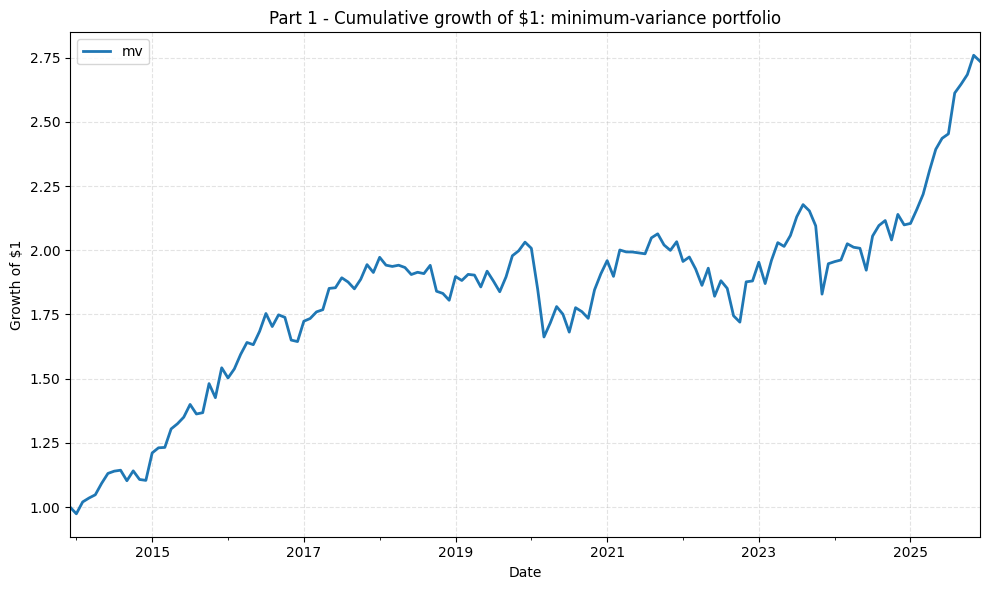

In [13]:
plot_cumulative(monthly, ["mv"], FIGURES / "part1_cumulative_mv.png",
                "Part 1 - Cumulative growth of $1: minimum-variance portfolio")

## 5. Part 2 - Value-Weighted benchmark (P_vw)

**What we do:** strict Section 2.3 cap-weighted index. Each month, weights are the previous-month market caps normalised to 1.

**Files saved here:** `part2_returns_vw.csv`, `part2_performance_vw.csv`, `part2_cumulative_vw.png`, `part2_cumulative_mv_vs_vw.png`.

In [14]:
vw_returns = monthly[["vw"]].copy()
vw_returns.to_csv(TABLES / "part2_returns_vw.csv", index_label="date")

part2_perf = summary_stats(monthly[["vw", "mv"]], rf=rf_monthly, benchmark="vw")
part2_perf.to_csv(TABLES / "part2_performance_vw.csv", index=False)

print("Part 2 - performance summary:")
display(part2_perf)
print("\nVW monthly returns (head):")
display(vw_returns.head())

Part 2 - performance summary:


,portfolio,annualized_return,annualized_volatility,annualized_rf,return_to_volatility,excess_sharpe_ratio,tracking_error_vs_vw,minimum_monthly_return,maximum_monthly_return,cumulative_return,terminal_growth
0,vw,0.0735,0.1289,0.0175,0.5704,0.4348,NaN,-0.1102,0.1317,1.1819,2.1819
1,mv,0.0914,0.1199,0.0175,0.7620,0.6163,0.1000,-0.1269,0.0969,1.7357,2.7357



VW monthly returns (head):


,vw
2014-01-31,-0.0440
2014-02-28,0.0194
2014-03-31,0.0028
2014-04-30,-0.0064
2014-05-30,0.0306


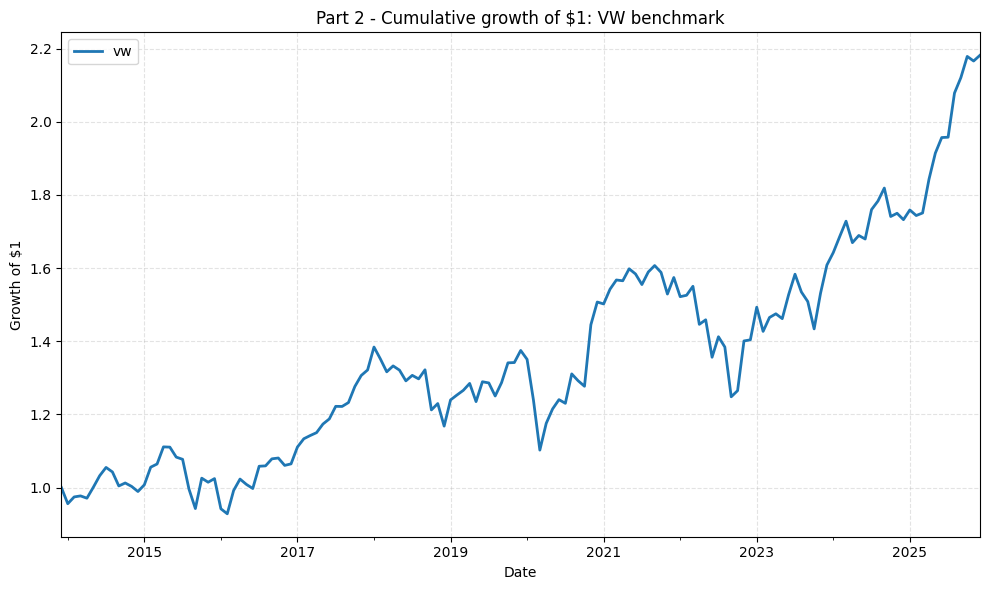

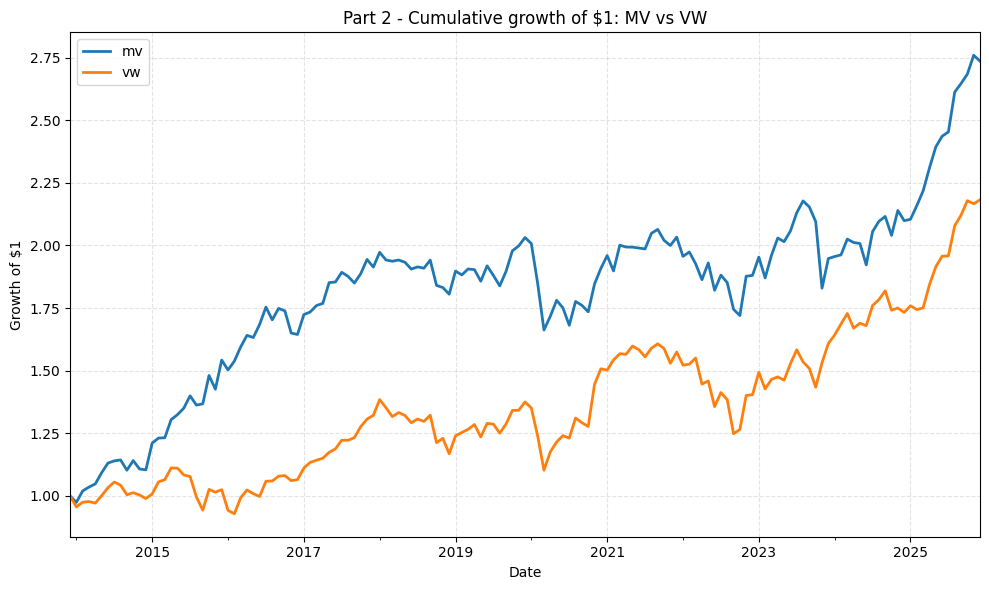

In [15]:
plot_cumulative(monthly, ["vw"], FIGURES / "part2_cumulative_vw.png",
                "Part 2 - Cumulative growth of $1: VW benchmark")
plot_cumulative(monthly, ["mv", "vw"], FIGURES / "part2_cumulative_mv_vs_vw.png",
                "Part 2 - Cumulative growth of $1: MV vs VW")

## 6. Part 3 - 50% carbon-footprint reduction

- $P_{mv,50}$: minimum-variance portfolio with carbon footprint capped at 50% of $P_{mv}$.
- $P_{vw,50}$: tracking-error minimisation versus $P_{vw}$, with carbon footprint capped at 50% of $P_{vw}$.

Section 3.1 - annual carbon metrics MV vs VW:


,year,implementation_year,portfolio,n_assets,waci_tco2e_per_musd_revenue,carbon_footprint_tco2e_per_musd_invested,carbon_limit,optimization_success,optimization_message
0,2013,2014,vw,233,175.4061,158.9359,158.9359,True,benchmark (drift)
1,2013,2014,mv,233,"1,252.9780",213.0860,NaN,True,Optimization terminated successfully
5,2014,2015,vw,246,155.5649,144.2472,144.2472,True,benchmark (drift)
6,2014,2015,mv,246,874.8299,509.4634,NaN,True,Optimization terminated successfully
10,2015,2016,vw,268,337.0091,188.2446,188.2446,True,benchmark (drift)
11,2015,2016,mv,268,"2,042.4186",442.3327,NaN,True,Optimization terminated successfully
15,2016,2017,vw,294,441.5001,240.3661,240.3661,True,benchmark (drift)
16,2016,2017,mv,294,"3,953.7711",508.5365,NaN,True,Optimization terminated successfully
20,2017,2018,vw,324,517.7791,211.3982,211.3982,True,benchmark (drift)
21,2017,2018,mv,324,"1,133.9444",499.6967,NaN,True,Optimization terminated successfully



Top-10 WACI contributors (head):


,year,rank,ISIN,name,country,ci_tco2e_per_musd_revenue,vw_weight,vw_waci_contribution
0,2013,1,HK0006000050,POWER ASSETS HOLDINGS,HK,"6,673.7625",0.0064,42.5441
1,2013,2,HK0002007356,CLP HOLDINGS,HK,"2,829.3242",0.0074,21.0162
2,2013,3,AU0000224040,WOODSIDE ENERGY GROUP,AU,"1,442.9466",0.0106,15.2437
3,2013,4,AU000000BHP4,BHP GROUP,AU,329.4661,0.0438,14.4315
4,2013,5,HK0019000162,SWIRE PACIFIC 'A',HK,"2,844.0929",0.0040,11.4762



Top-10 CF contributors (head):


,year,rank,ISIN,name,country,cf_per_weight_tco2e_per_musd_invested,vw_weight,vw_cf_contribution
0,2013,1,JP3551200003,ELEC.POWER DEV.,JP,"14,430.5033",0.0013,18.7062
1,2013,2,HK0002007356,CLP HOLDINGS,HK,"1,780.6195",0.0074,13.2264
2,2013,3,AU000000BHP4,BHP GROUP,AU,173.6959,0.0438,7.6084
3,2013,4,JP3753000003,NIPPON YUSEN KK,JP,"5,197.4912",0.0014,7.0303
4,2013,5,JP3362700001,MITSUI OSK LINES,JP,"4,941.7330",0.0013,6.5892


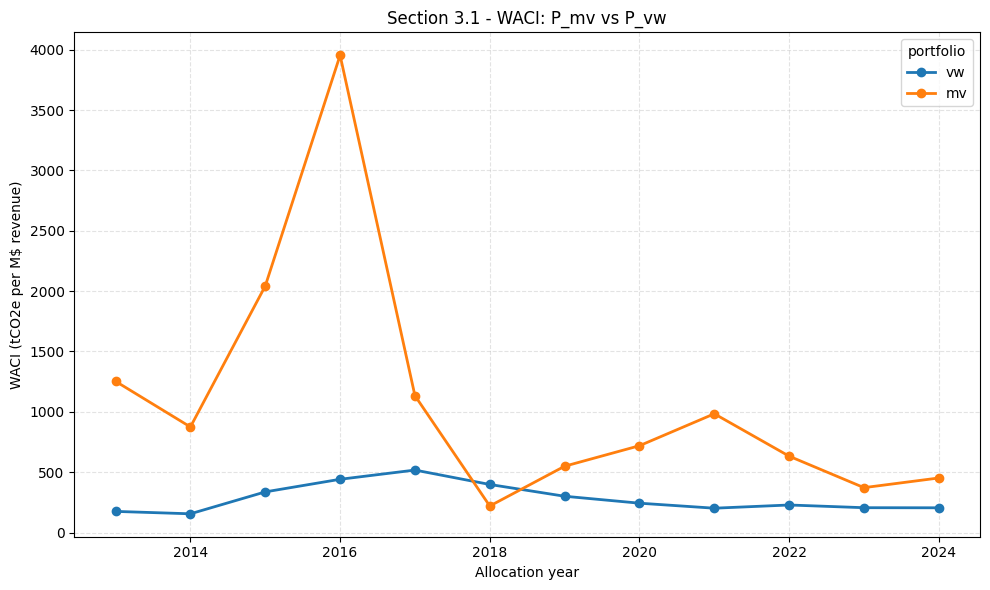

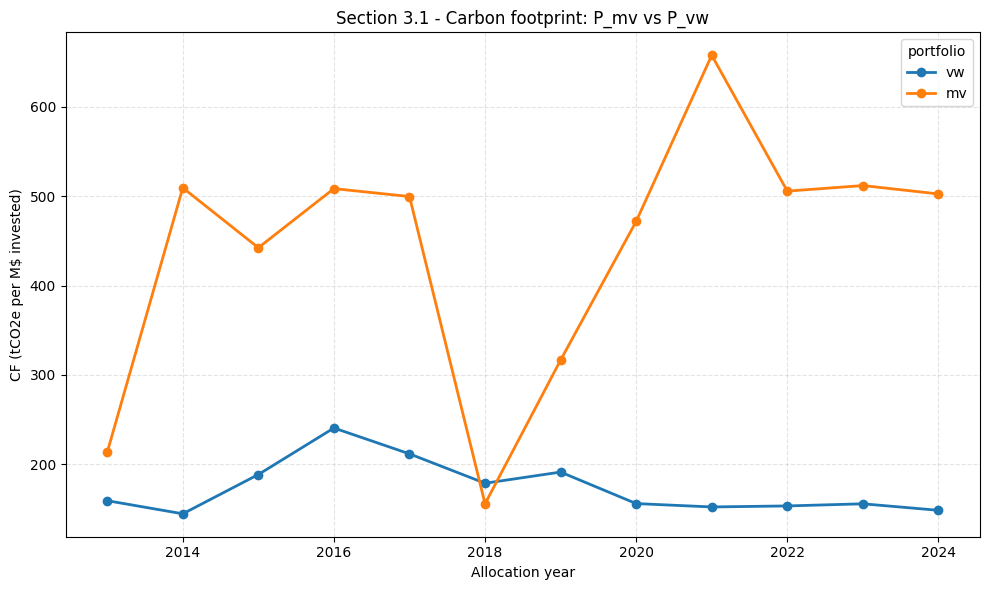

In [16]:
metrics_3_1 = annual[annual["portfolio"].isin(["vw_drift", "mv"])].copy()
metrics_3_1["portfolio"] = metrics_3_1["portfolio"].replace({"vw_drift": "vw"})
metrics_3_1.to_csv(TABLES / "part3_carbon_metrics_mv_vw.csv", index=False)
waci_top.to_csv(TABLES / "part3_top10_waci_contributors.csv", index=False)
cf_top.to_csv(TABLES / "part3_top10_cf_contributors.csv", index=False)

print("Section 3.1 - annual carbon metrics MV vs VW:")
display(metrics_3_1.head(12))
print("\nTop-10 WACI contributors (head):")
display(waci_top.head())
print("\nTop-10 CF contributors (head):")
display(cf_top.head())

plot_annual(metrics_3_1, "waci_tco2e_per_musd_revenue", ["vw", "mv"],
            FIGURES / "part3_waci_mv_vs_vw.png",
            "Section 3.1 - WACI: P_mv vs P_vw", "WACI (tCO2e per M$ revenue)")
plot_annual(metrics_3_1, "carbon_footprint_tco2e_per_musd_invested", ["vw", "mv"],
            FIGURES / "part3_carbon_footprint_mv_vs_vw.png",
            "Section 3.1 - Carbon footprint: P_mv vs P_vw", "CF (tCO2e per M$ invested)")

Section 3.2 - MV vs MV(-50%) summary:


,portfolio,annualized_return,annualized_volatility,annualized_rf,return_to_volatility,excess_sharpe_ratio,tracking_error_vs_vw,minimum_monthly_return,maximum_monthly_return,cumulative_return,terminal_growth
1,mv,0.0914,0.1199,0.0175,0.7620,0.6163,0.1000,-0.1269,0.0969,1.7357,2.7357
2,mv_50,0.0888,0.1275,0.0175,0.6967,0.5597,0.1067,-0.1597,0.0994,1.6231,2.6231


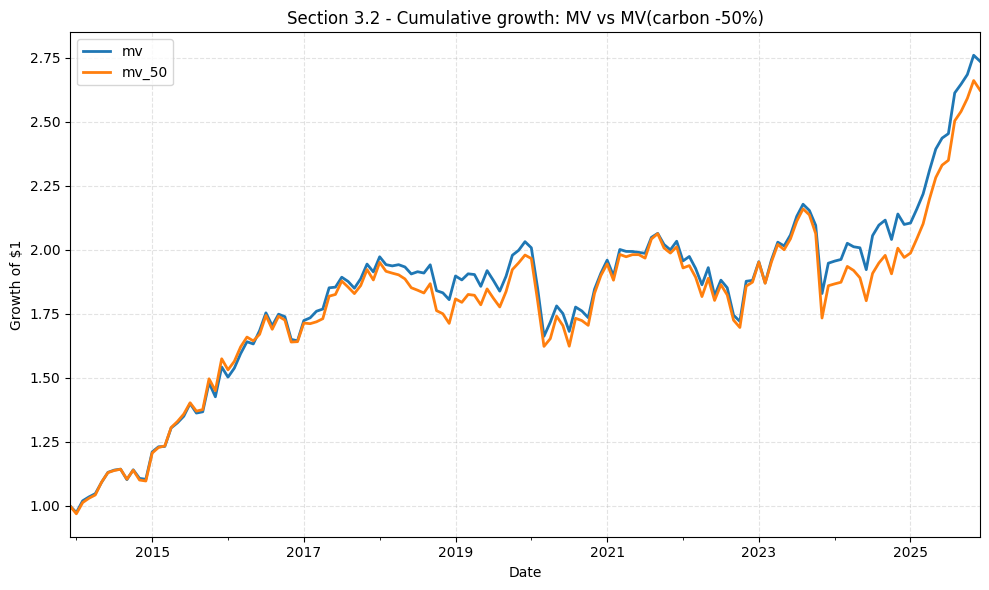

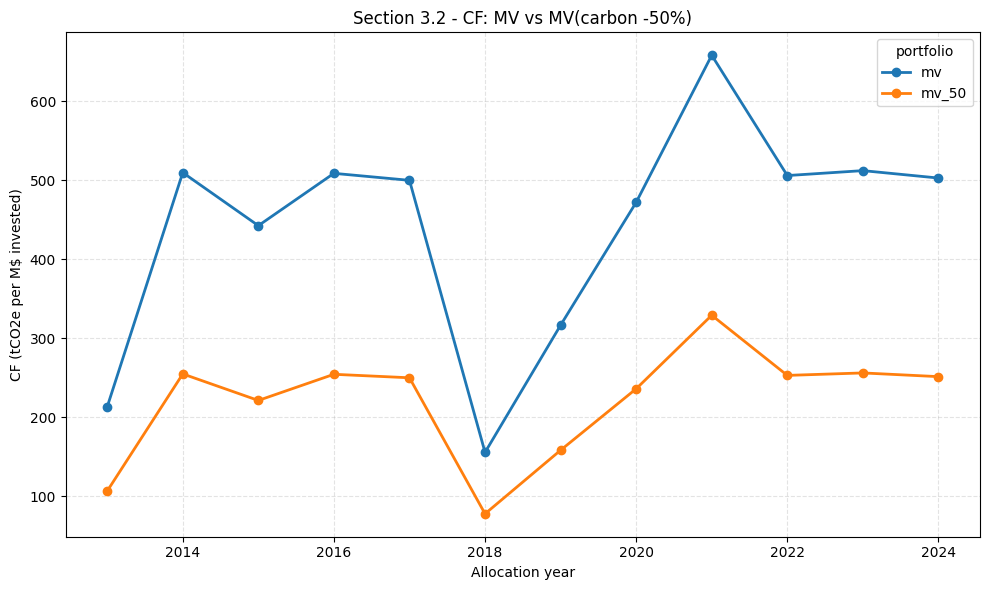

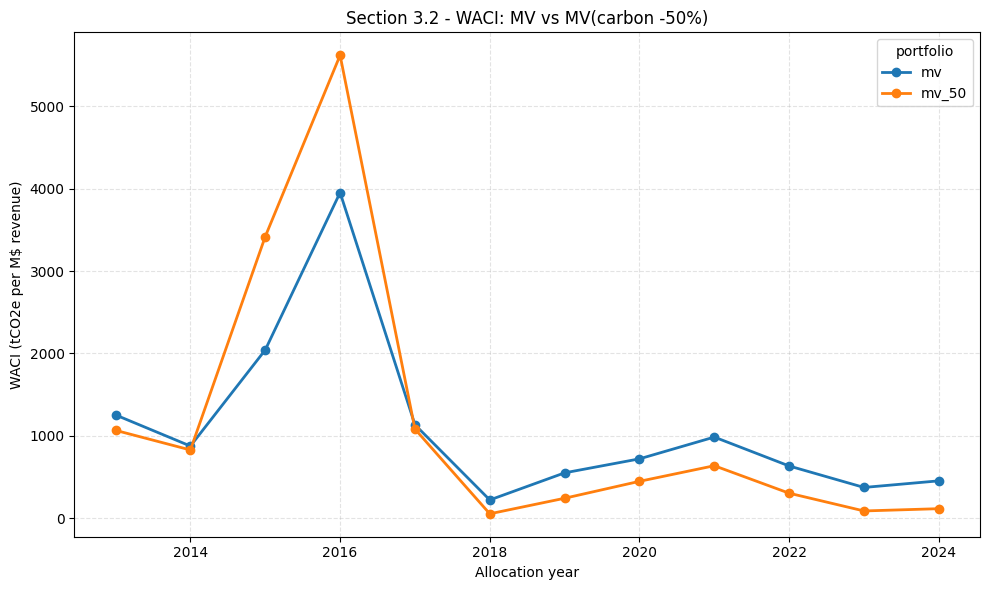

In [17]:
monthly[["mv", "mv_50"]].to_csv(TABLES / "part3_returns_mv_carbon50.csv", index_label="date")
summary_mv = summary_stats(monthly[["vw", "mv", "mv_50"]], rf=rf_monthly, benchmark="vw")
summary_mv = summary_mv[summary_mv["portfolio"].isin(["mv", "mv_50"])]
summary_mv.to_csv(TABLES / "part3_summary_mv_vs_mv_carbon50.csv", index=False)
weights[weights["portfolio"].isin(["mv", "mv_50"])].to_csv(
    TABLES / "part3_weights_mv_carbon50.csv", index=False)
slack_table[slack_table["portfolio"] == "mv_50"].to_csv(
    TABLES / "part3_constraint_slack_mv_carbon50.csv", index=False)

print("Section 3.2 - MV vs MV(-50%) summary:")
display(summary_mv)

plot_cumulative(monthly, ["mv", "mv_50"],
                FIGURES / "part3_cumulative_mv_vs_mv_carbon50.png",
                "Section 3.2 - Cumulative growth: MV vs MV(carbon -50%)")
plot_annual(annual, "carbon_footprint_tco2e_per_musd_invested", ["mv", "mv_50"],
            FIGURES / "part3_cf_mv_vs_mv_carbon50.png",
            "Section 3.2 - CF: MV vs MV(carbon -50%)", "CF (tCO2e per M$ invested)")
plot_annual(annual, "waci_tco2e_per_musd_revenue", ["mv", "mv_50"],
            FIGURES / "part3_waci_mv_vs_mv_carbon50.png",
            "Section 3.2 - WACI: MV vs MV(carbon -50%)", "WACI (tCO2e per M$ revenue)")

Section 3.3 - VW vs VW(-50%) summary:


,portfolio,annualized_return,annualized_volatility,annualized_rf,return_to_volatility,excess_sharpe_ratio,tracking_error_vs_vw,minimum_monthly_return,maximum_monthly_return,cumulative_return,terminal_growth
0,vw,0.0735,0.1289,0.0175,0.5704,0.4348,NaN,-0.1102,0.1317,1.1819,2.1819
1,vw_50,0.0736,0.1345,0.0175,0.5469,0.4170,0.0292,-0.1158,0.1120,1.1635,2.1635


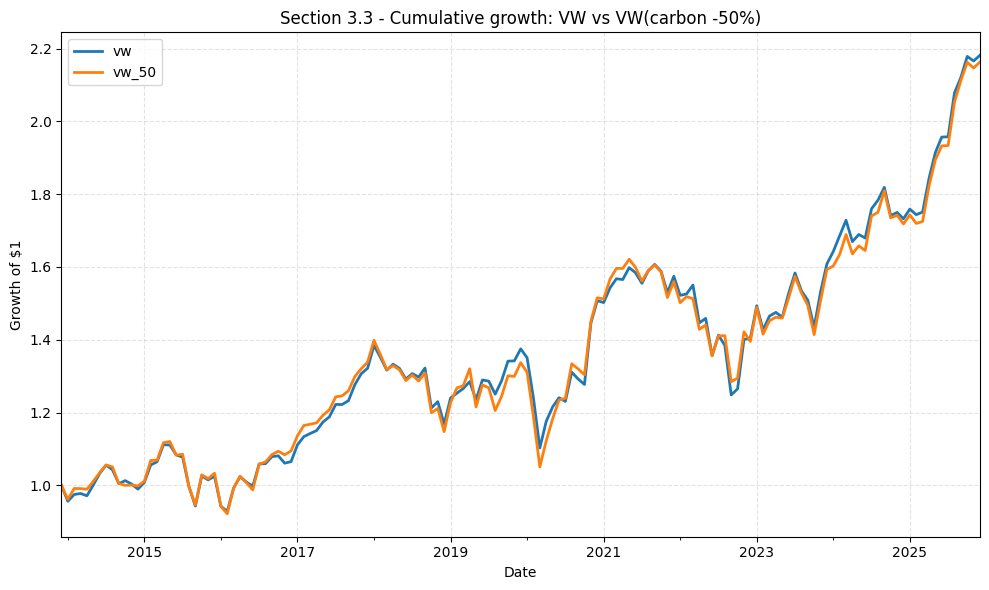

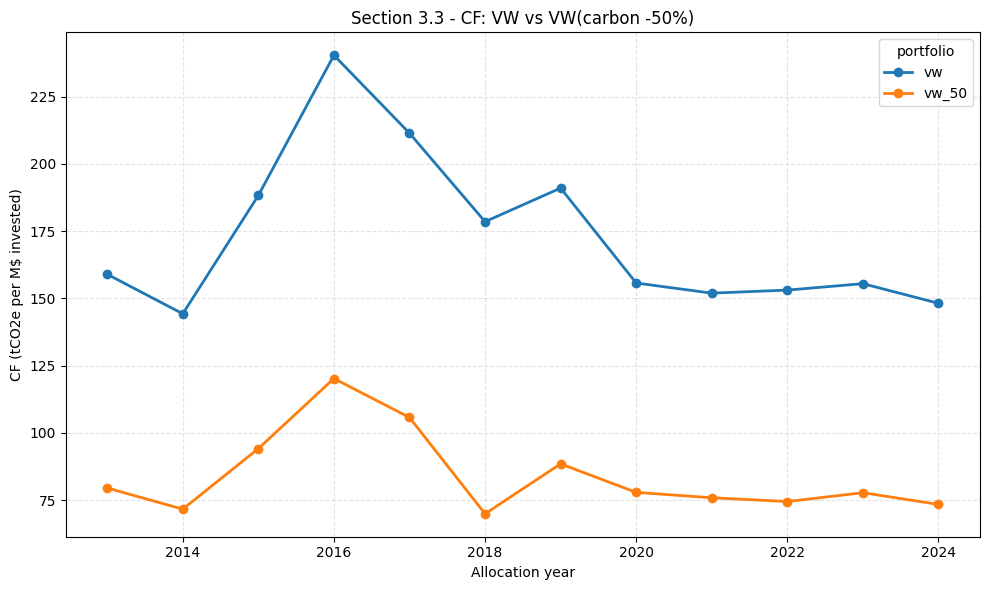

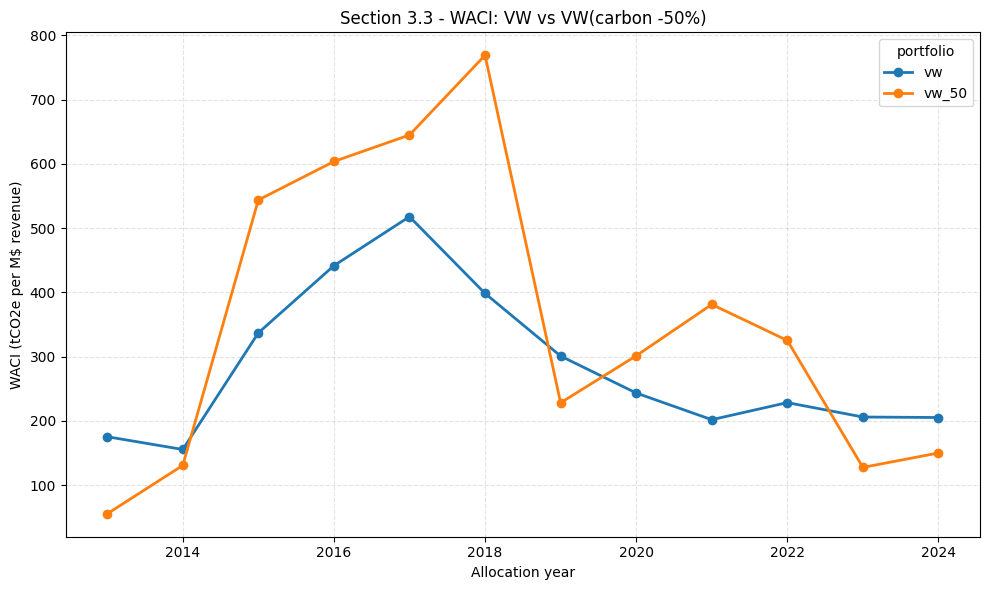

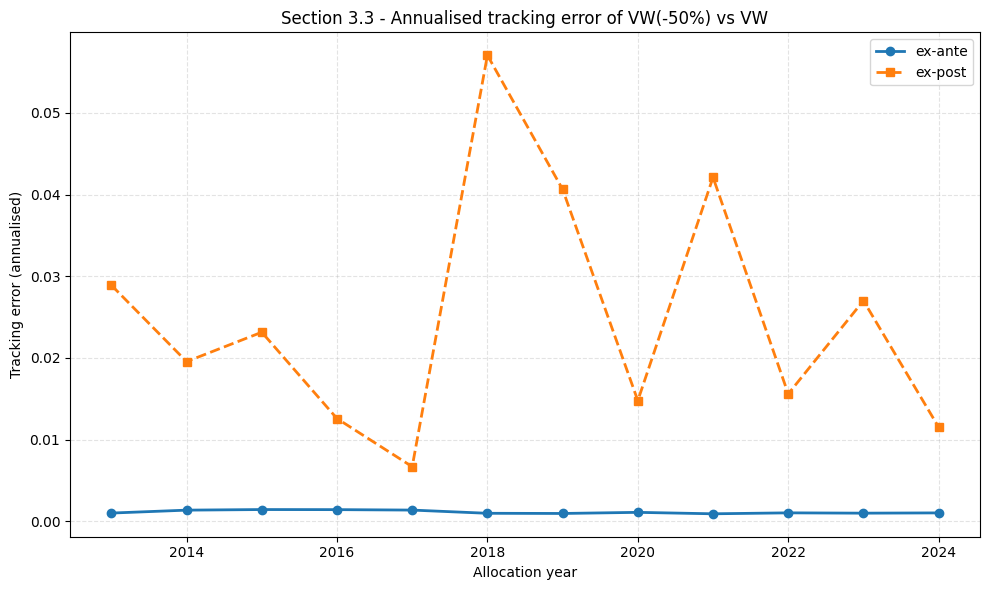

In [18]:
monthly[["vw", "vw_50"]].to_csv(TABLES / "part3_returns_vw_carbon50.csv", index_label="date")
summary_vw = summary_stats(monthly[["vw", "vw_50"]], rf=rf_monthly, benchmark="vw")
summary_vw.to_csv(TABLES / "part3_summary_vw_vs_vw_carbon50.csv", index=False)

weights_vw_view = weights.copy()
weights_vw_view.loc[weights_vw_view["portfolio"] == "vw_drift", "portfolio"] = "vw"
weights_vw_view[weights_vw_view["portfolio"].isin(["vw", "vw_50"])].to_csv(
    TABLES / "part3_weights_vw_carbon50.csv", index=False)
te_table[te_table["portfolio"] == "vw_50"].to_csv(
    TABLES / "part3_tracking_error_vw_carbon50.csv", index=False)
slack_table[slack_table["portfolio"] == "vw_50"].to_csv(
    TABLES / "part3_constraint_slack_vw_carbon50.csv", index=False)

print("Section 3.3 - VW vs VW(-50%) summary:")
display(summary_vw)

plot_cumulative(monthly, ["vw", "vw_50"],
                FIGURES / "part3_cumulative_vw_vs_vw_carbon50.png",
                "Section 3.3 - Cumulative growth: VW vs VW(carbon -50%)")

annual_vw_view = annual.copy()
annual_vw_view["portfolio"] = annual_vw_view["portfolio"].replace({"vw_drift": "vw"})
plot_annual(annual_vw_view, "carbon_footprint_tco2e_per_musd_invested", ["vw", "vw_50"],
            FIGURES / "part3_cf_vw_vs_vw_carbon50.png",
            "Section 3.3 - CF: VW vs VW(carbon -50%)", "CF (tCO2e per M$ invested)")
plot_annual(annual_vw_view, "waci_tco2e_per_musd_revenue", ["vw", "vw_50"],
            FIGURES / "part3_waci_vw_vs_vw_carbon50.png",
            "Section 3.3 - WACI: VW vs VW(carbon -50%)", "WACI (tCO2e per M$ revenue)")

te_vw50 = te_table[te_table["portfolio"] == "vw_50"]
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(te_vw50["year"], te_vw50["ex_ante_tracking_error_annual"], marker="o", linewidth=2, label="ex-ante")
ax.plot(te_vw50["year"], te_vw50["ex_post_tracking_error_annual"],  marker="s", linewidth=2, linestyle="--", label="ex-post")
ax.set_title("Section 3.3 - Annualised tracking error of VW(-50%) vs VW")
ax.set_xlabel("Allocation year"); ax.set_ylabel("Tracking error (annualised)")
ax.grid(True, linestyle="--", alpha=0.35); ax.legend()
fig.tight_layout(); fig.savefig(FIGURES / "part3_tracking_error_vw_carbon50.png", dpi=160)
plt.show()

## 7. Part 4 - Net-Zero trajectory $P_{vw,NZ}$

The carbon cap declines by 10% per year from a 2013 anchor equal to the carbon footprint of the value-weighted benchmark:

$$C_Y = (1 - \\theta)^{Y - 2013 + 1} \\cdot CF(P_{vw,2013}), \\qquad \\theta = 10\\%.$$

In [19]:
monthly[["vw", "vw_nz"]].to_csv(TABLES / "part4_returns_vw_netzero.csv", index_label="date")
joint_monthly = monthly[["vw", "vw_50", "vw_nz"]].copy()
summary_part4 = summary_stats(joint_monthly, rf=rf_monthly, benchmark="vw")
summary_part4.to_csv(TABLES / "part4_summary_vw_vs_carbon50_vs_netzero.csv", index=False)
weights[weights["portfolio"] == "vw_nz"].to_csv(
    TABLES / "part4_weights_vw_netzero.csv", index=False)
path_table.to_csv(TABLES / "part4_netzero_target_vs_realized_cf.csv", index=False)
te_table[te_table["portfolio"] == "vw_nz"].to_csv(
    TABLES / "part4_tracking_error_vw_netzero.csv", index=False)
slack_table[slack_table["portfolio"] == "vw_nz"].to_csv(
    TABLES / "part4_constraint_slack_vw_netzero.csv", index=False)

print("Part 4 - VW vs VW(-50%) vs VW(NZ) summary:")
display(summary_part4)
print("\nPart 4 - net-zero cap path vs realised CF:")
display(path_table)

Part 4 - VW vs VW(-50%) vs VW(NZ) summary:


,portfolio,annualized_return,annualized_volatility,annualized_rf,return_to_volatility,excess_sharpe_ratio,tracking_error_vs_vw,minimum_monthly_return,maximum_monthly_return,cumulative_return,terminal_growth
0,vw,0.0735,0.1289,0.0175,0.5704,0.4348,NaN,-0.1102,0.1317,1.1819,2.1819
1,vw_50,0.0736,0.1345,0.0175,0.5469,0.4170,0.0292,-0.1158,0.1120,1.1635,2.1635
2,vw_nz,0.0750,0.1349,0.0175,0.5560,0.4265,0.0287,-0.1187,0.1161,1.2000,2.2000



Part 4 - net-zero cap path vs realised CF:


,year,implementation_year,anchor_cf_vw_2013,theta,carbon_limit_nz,carbon_footprint_vw,carbon_footprint_vw_nz,slack,feasible_within_1e-6,optimizer_success
0,2013,2014,158.9359,0.1000,143.0423,158.9359,141.3465,1.6958,True,True
1,2014,2015,158.9359,0.1000,128.7381,144.2472,107.6205,21.1175,True,True
2,2015,2016,158.9359,0.1000,115.8643,188.2446,115.8643,0.0000,True,True
3,2016,2017,158.9359,0.1000,104.2778,240.3661,104.2778,0.0000,True,True
4,2017,2018,158.9359,0.1000,93.8500,211.3982,93.8500,0.0000,True,True
5,2018,2019,158.9359,0.1000,84.4650,178.4931,70.5492,13.9159,True,True
6,2019,2020,158.9359,0.1000,76.0185,190.9813,76.0185,0.0000,True,True
7,2020,2021,158.9359,0.1000,68.4167,155.6882,68.4167,0.0000,True,True
8,2021,2022,158.9359,0.1000,61.5750,151.9173,61.5750,0.0000,True,True
9,2022,2023,158.9359,0.1000,55.4175,153.0560,55.4175,0.0000,True,True


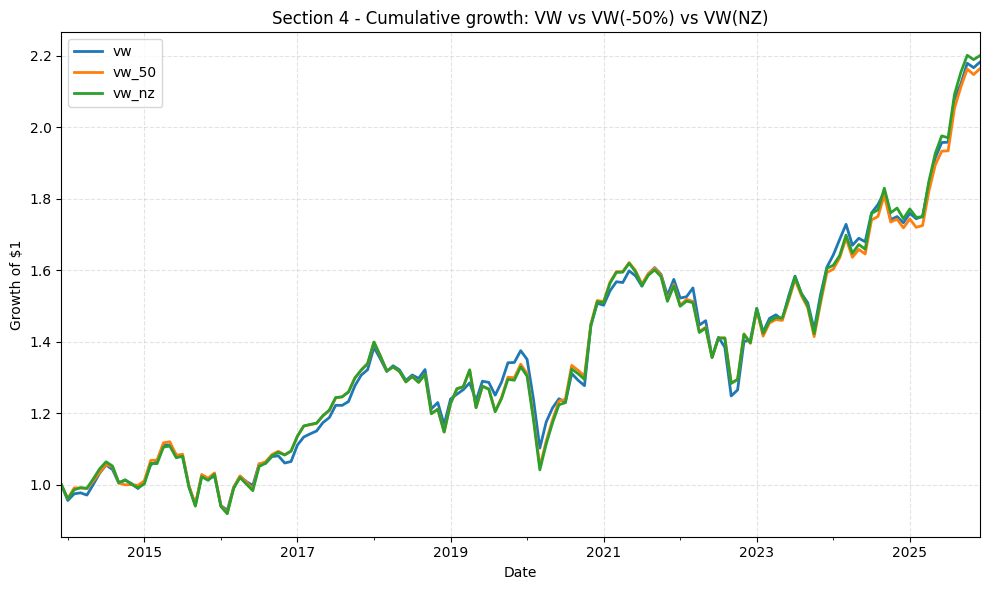

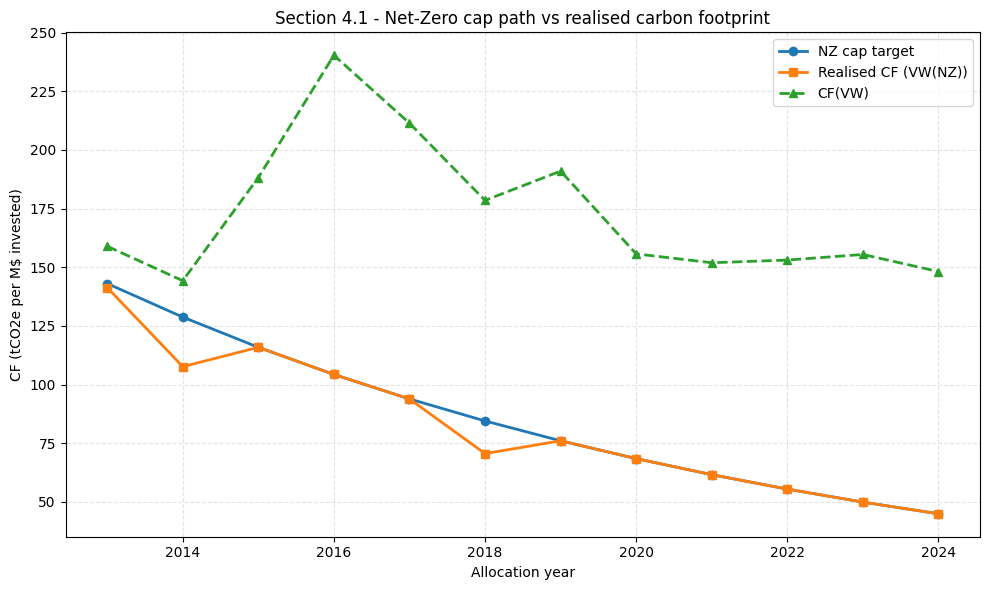

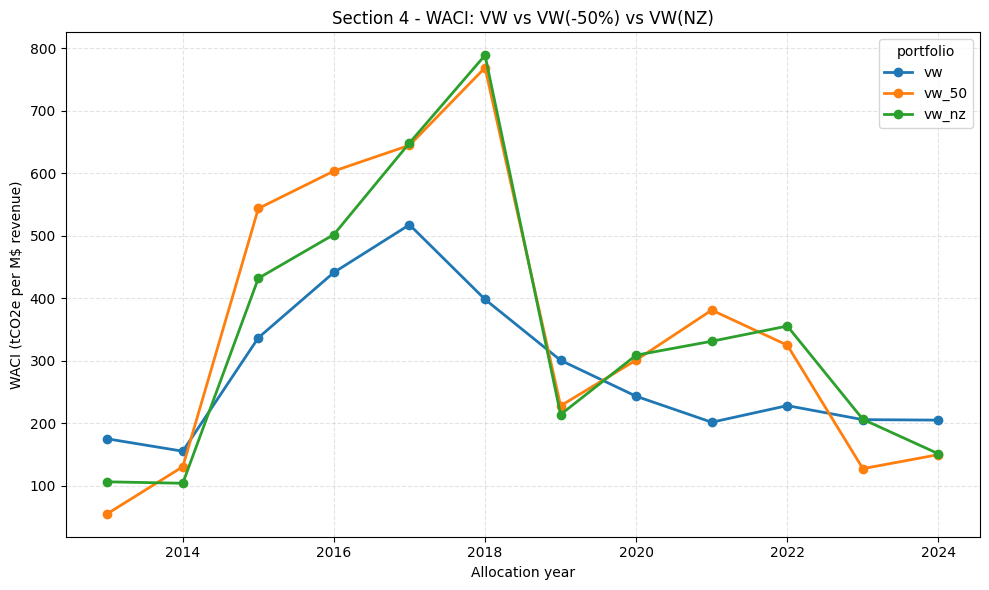

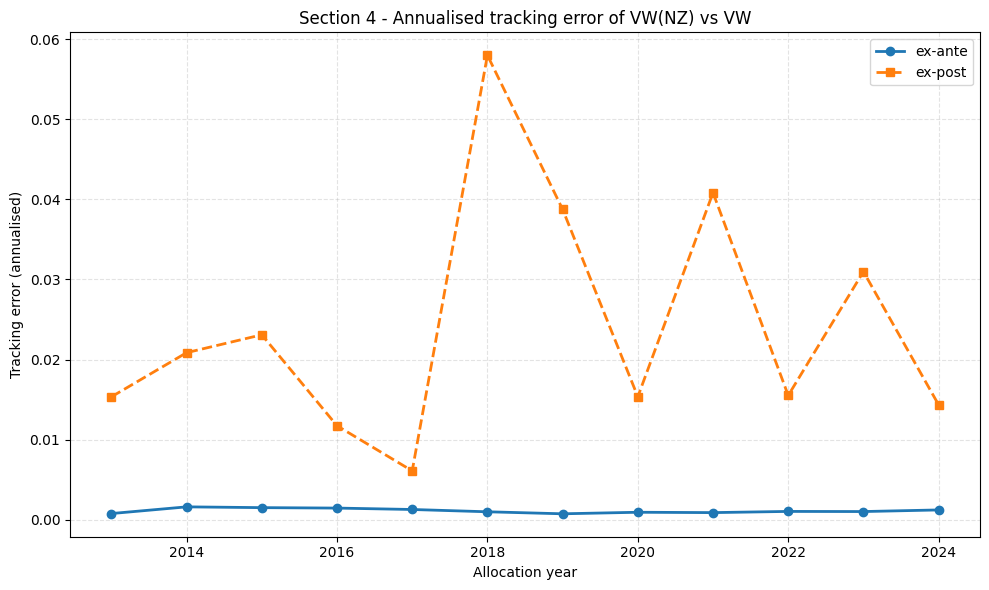

In [20]:
plot_cumulative(joint_monthly, ["vw", "vw_50", "vw_nz"],
                FIGURES / "part4_cumulative_vw_vs_carbon50_vs_netzero.png",
                "Section 4 - Cumulative growth: VW vs VW(-50%) vs VW(NZ)")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(path_table["year"], path_table["carbon_limit_nz"],       marker="o", linewidth=2, label="NZ cap target")
ax.plot(path_table["year"], path_table["carbon_footprint_vw_nz"], marker="s", linewidth=2, label="Realised CF (VW(NZ))")
ax.plot(path_table["year"], path_table["carbon_footprint_vw"],    marker="^", linewidth=2, linestyle="--", label="CF(VW)")
ax.set_title("Section 4.1 - Net-Zero cap path vs realised carbon footprint")
ax.set_xlabel("Allocation year"); ax.set_ylabel("CF (tCO2e per M$ invested)")
ax.grid(True, linestyle="--", alpha=0.35); ax.legend()
fig.tight_layout(); fig.savefig(FIGURES / "part4_cf_target_vs_realized.png", dpi=160)
plt.show()

annual_view = annual.copy()
annual_view["portfolio"] = annual_view["portfolio"].replace({"vw_drift": "vw"})
waci_panel = annual_view[annual_view["portfolio"].isin(["vw", "vw_50", "vw_nz"])]
plot_annual(waci_panel, "waci_tco2e_per_musd_revenue", ["vw", "vw_50", "vw_nz"],
            FIGURES / "part4_waci_vw_vs_carbon50_vs_netzero.png",
            "Section 4 - WACI: VW vs VW(-50%) vs VW(NZ)", "WACI (tCO2e per M$ revenue)")

te_nz = te_table[te_table["portfolio"] == "vw_nz"]
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(te_nz["year"], te_nz["ex_ante_tracking_error_annual"], marker="o", linewidth=2, label="ex-ante")
ax.plot(te_nz["year"], te_nz["ex_post_tracking_error_annual"],  marker="s", linewidth=2, linestyle="--", label="ex-post")
ax.set_title("Section 4 - Annualised tracking error of VW(NZ) vs VW")
ax.set_xlabel("Allocation year"); ax.set_ylabel("Tracking error (annualised)")
ax.grid(True, linestyle="--", alpha=0.35); ax.legend()
fig.tight_layout(); fig.savefig(FIGURES / "part4_tracking_error_vw_netzero.png", dpi=160)
plt.show()

## 8. Final performance summary

In [21]:
rf_by_month = rf_monthly.copy()
rf_by_month.index = rf_by_month.index.to_period("M")
validation_rows = []
for col in monthly.columns:
    r = monthly[col].dropna()
    if not len(r):
        continue
    rf_aligned = rf_by_month.reindex(r.index.to_period("M"))
    valid_rf   = rf_aligned.notna().to_numpy()
    ann_ret    = float(r.mean() * 12.0)
    ann_vol    = r.std(ddof=0) * np.sqrt(12.0)
    ann_rf     = float(rf_aligned.dropna().mean() * 12.0) if valid_rf.any() else 0.0
    if ann_vol > 0 and valid_rf.any():
        ann_excess = float((r.to_numpy()[valid_rf] - rf_aligned.to_numpy()[valid_rf]).mean() * 12.0)
        sharpe     = ann_excess / ann_vol
    elif ann_vol > 0:
        sharpe = ann_ret / ann_vol
    else:
        sharpe = np.nan
    validation_rows.append({
        "portfolio":             col,
        "start_date":            str(r.index.min().date()),
        "end_date":              str(r.index.max().date()),
        "n_obs":                 int(len(r)),
        "n_rf_matches":          int(valid_rf.sum()),
        "annualized_return":     ann_ret,
        "annualized_volatility": ann_vol,
        "aligned_annualized_rf": ann_rf,
        "sharpe_ratio":          sharpe,
    })
validation_df = pd.DataFrame(validation_rows)
print("Validation - RF aligned per portfolio:")
display(validation_df)

Validation - RF aligned per portfolio:


,portfolio,start_date,end_date,n_obs,n_rf_matches,annualized_return,annualized_volatility,aligned_annualized_rf,sharpe_ratio
0,vw,2014-01-31,2025-12-31,144,144,0.0735,0.1289,0.0175,0.4348
1,vw_drift,2014-01-31,2025-12-31,144,144,0.0735,0.1319,0.0175,0.4244
2,mv,2014-01-31,2025-12-31,144,144,0.0914,0.1199,0.0175,0.6163
3,mv_50,2014-01-31,2025-12-31,144,144,0.0888,0.1275,0.0175,0.5597
4,vw_50,2014-01-31,2025-12-31,144,144,0.0736,0.1345,0.0175,0.4170
5,vw_nz,2014-01-31,2025-12-31,144,144,0.0750,0.1349,0.0175,0.4265


In [22]:
print("Allocation years:", int(annual["year"].min()), "to", int(annual["year"].max()))
print("Implementation years:", int(annual["implementation_year"].min()), "to", int(annual["implementation_year"].max()))
print("Portfolio labels:", list(monthly.columns))
terminal_values = (1.0 + monthly[["vw", "mv", "mv_50", "vw_50", "vw_nz"]]).prod()
print("Terminal cumulative values by portfolio:")
display(terminal_values.rename("terminal_growth").to_frame())

Allocation years: 2013 to 2024
Implementation years: 2014 to 2025
Portfolio labels: ['vw', 'vw_drift', 'mv', 'mv_50', 'vw_50', 'vw_nz']
Terminal cumulative values by portfolio:


,terminal_growth
vw,2.1819
mv,2.7357
mv_50,2.6231
vw_50,2.1635
vw_nz,2.2000


In [23]:
final_summary = summary_stats(monthly[["vw", "mv", "mv_50", "vw_50", "vw_nz"]],
                              rf=rf_monthly, benchmark="vw")
final_summary.to_csv(TABLES / "final_performance_summary.csv", index=False)
print("Final performance summary:")
display(final_summary)

Final performance summary:


,portfolio,annualized_return,annualized_volatility,annualized_rf,return_to_volatility,excess_sharpe_ratio,tracking_error_vs_vw,minimum_monthly_return,maximum_monthly_return,cumulative_return,terminal_growth
0,vw,0.0735,0.1289,0.0175,0.5704,0.4348,NaN,-0.1102,0.1317,1.1819,2.1819
1,mv,0.0914,0.1199,0.0175,0.7620,0.6163,0.1000,-0.1269,0.0969,1.7357,2.7357
2,mv_50,0.0888,0.1275,0.0175,0.6967,0.5597,0.1067,-0.1597,0.0994,1.6231,2.6231
3,vw_50,0.0736,0.1345,0.0175,0.5469,0.4170,0.0292,-0.1158,0.1120,1.1635,2.1635
4,vw_nz,0.0750,0.1349,0.0175,0.5560,0.4265,0.0287,-0.1187,0.1161,1.2000,2.2000


## 9. Short conclusion

The results show that the minimum-variance portfolio performs better than the value-weighted benchmark in risk-adjusted terms. It has a higher annualised return, slightly lower volatility, and a higher Sharpe ratio.

The 50% carbon constraint is feasible for both the minimum-variance and the benchmark-relative portfolios. For $P_{mv,50}$, the constraint creates a moderate cost: volatility increases and the Sharpe ratio decreases compared with the unconstrained portfolio. For $P_{vw,50}$, the portfolio achieves a large carbon-footprint reduction while keeping tracking error low.

The Net-Zero portfolio also remains relatively close to the benchmark. Even though the carbon cap becomes stricter over time, the tracking error stays contained, suggesting that a gradual decarbonisation path can be implemented without a very large additional active-risk cost.

### Limitations

- The analysis depends on the availability and quality of carbon data. Some firms are excluded because emissions, revenues, market capitalisation, or price data are missing or unreliable.
- The optimisation relies on historical covariance estimates, which are still estimated with error and can change over time.
- The backtest does not include transaction costs, taxes, liquidity limits, or turnover constraints.
- Lowering the portfolio carbon footprint does not necessarily prove a direct reduction in real-world emissions.
- Parameter sensitivity: results may vary with different values of the ridge parameter, the estimation window, or the stale-price threshold.

### Use of Large Language Models

Claude (Anthropic) was used as a coding assistant to review the notebook structure, debug implementation issues, and improve code readability. The final methodology, interpretation of results, and academic responsibility remain with the group.